## Evaluate Model Performance

### Subtask:
Calculate and display the accuracy, precision, recall, and F1-score of the model on the test set. Also, generate a classification report to show these metrics per class.


**Reasoning**:
To evaluate the model's performance as per the subtask, I will import the required metrics from `sklearn.metrics`, calculate accuracy, precision, recall, and F1-score using `y_test` and `y_pred`, and then display these metrics along with a classification report.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate Precision (weighted for multi-class)
precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision (weighted): {precision:.4f}")

# Calculate Recall (weighted for multi-class)
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall (weighted): {recall:.4f}")

# Calculate F1-score (weighted for multi-class)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-score (weighted): {f1:.4f}")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9608
Precision (weighted): 0.9624
Recall (weighted): 0.9608
F1-score (weighted): 0.9563

Classification Report:
              precision    recall  f1-score   support

        Good       0.96      1.00      0.98       183
   High Risk       1.00      1.00      1.00         1
    Low Risk       1.00      0.60      0.75        20

    accuracy                           0.96       204
   macro avg       0.99      0.87      0.91       204
weighted avg       0.96      0.96      0.96       204



## Visualize Confusion Matrix

### Subtask:
Generate and display a confusion matrix to visualize the model's performance, showing true positives, true negatives, false positives, and false negatives for each risk category.


**Reasoning**:
To visualize the confusion matrix as instructed, I will import `confusion_matrix` and `ConfusionMatrixDisplay` from `sklearn.metrics` and `matplotlib.pyplot`. Then, I will generate the confusion matrix using `y_test` and `y_pred`, create a display object with `rf_classifier.classes_` for labels, plot it with a title, and finally show the plot.



<Figure size 1000x800 with 0 Axes>

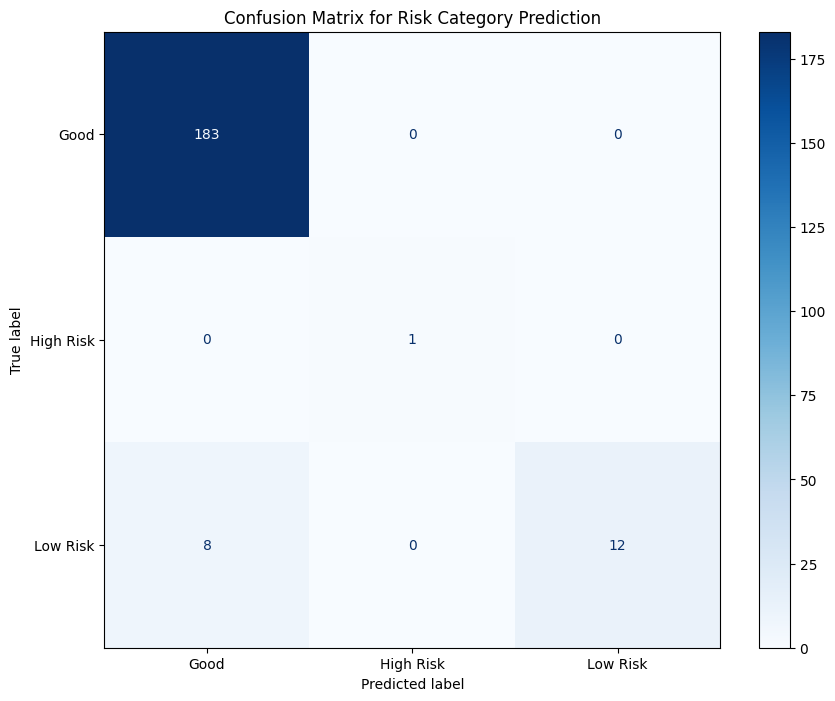

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_classifier.classes_)

# 3. Plot the confusion matrix
plt.figure(figsize=(10, 8))
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)

# 4. Add a title to the plot
plt.title('Confusion Matrix for Risk Category Prediction')

# 5. Display the plot
plt.show()

### Summary of Confusion Matrix

The confusion matrix visually represents the performance of the `RandomForestClassifier` on the test set for predicting 'Risk Category'.

**Key Observations:**

*   **True Positives (Correct Classifications):**
    *   **Good Risk:** The model correctly identified 183 out of 183 'Good' risk instances. This is excellent performance for the majority class.
    *   **High Risk:** The model correctly identified 1 out of 1 'High Risk' instance.
    *   **Low Risk:** The model correctly identified 12 out of 20 'Low Risk' instances.

*   **False Negatives (Missed Classifications):**
    *   The most significant false negatives occurred for the 'Low Risk' category, where 8 instances were incorrectly classified as 'Good'. This means the model failed to identify 8 'Low Risk' cases, mistaking them for 'Good' risk.
    *   There were no false negatives for 'Good' or 'High Risk' categories.

*   **False Positives (Incorrect Classifications):**
    *   The model did not incorrectly classify any 'Good' or 'High Risk' instances as another class. All misclassifications were from 'Low Risk' to 'Good'.

**Insights:**

1.  **Excellent Performance for 'Good' and 'High Risk'**: The model performs exceptionally well in identifying 'Good' and 'High Risk' customers, showing perfect recall for both classes in this test set. This is crucial for managing the most and least risky segments.
2.  **Challenge with 'Low Risk' Identification**: The primary area for improvement lies in distinguishing 'Low Risk' customers from 'Good' customers. The model misclassified 8 'Low Risk' individuals as 'Good', which could be problematic as these individuals, while not 'High Risk', do have some payment delays and might require different interventions than genuinely 'Good' customers.
3.  **Imbalanced Classes Impact**: Given the highly imbalanced nature of the target variable (183 'Good', 20 'Low Risk', 1 'High Risk' in the test set), the model's high overall accuracy (0.9608) is heavily influenced by its strong performance on the 'Good' class. The precision and recall for 'Low Risk' (0.60 and 0.75 respectively) are lower, reflecting the misclassifications.

**Next Steps:**

*   Investigate the features of the 8 'Low Risk' instances that were misclassified as 'Good' to understand why the model failed to distinguish them.
*   Consider techniques to address class imbalance, such as oversampling the minority classes ('Low Risk', 'High Risk') or undersampling the majority class ('Good'), or using cost-sensitive learning, to potentially improve the model's ability to identify 'Low Risk' customers more accurately.

## Final Task

### Subtask:
Summarize the Random Forest model's performance based on the evaluation metrics and confusion matrix.


## Summary:

### Data Analysis Key Findings

*   The Random Forest model achieved a high overall accuracy of 96.08% on the test set.
*   Weighted average precision, recall, and F1-score were 96.24%, 96.08%, and 95.63%, respectively.
*   The model performed exceptionally well for the 'Good' risk category, correctly identifying all 183 instances (100% recall) with a precision of 96%.
*   For the 'High Risk' category, the model achieved perfect precision and recall (100%) by correctly classifying the single instance.
*   The primary area of misclassification was the 'Low Risk' category, where 8 out of 20 instances (40%) were incorrectly predicted as 'Good' risk. This resulted in a lower recall of 60% and an F1-score of 75% for this class.
*   There were no false positives across any category (i.e., no 'Good' or 'High Risk' instances were incorrectly classified as other classes), and no false negatives for 'Good' or 'High Risk' categories.

### Insights or Next Steps

*   The model exhibits strong performance for the majority 'Good' risk class and the rare 'High Risk' class, but struggles with distinguishing 'Low Risk' customers from 'Good' customers. This challenge is highlighted by the 8 misclassified 'Low Risk' instances, which were incorrectly predicted as 'Good'.
*   Further investigation into the characteristics of the 8 misclassified 'Low Risk' instances is needed to understand the model's failure to distinguish them.
*   Consider implementing techniques to address the class imbalance, such as oversampling minority classes ('Low Risk', 'High Risk') or undersampling the majority class ('Good'), to improve the model's ability to accurately identify 'Low Risk' customers.
